# Week 07 — Spatial Localization in MRI: k-space & Image Formation

Lecture notes (from the Oct 6 session). We go from **slice selection** to full **in-plane
localization**: frequency and phase encoding, **k-space**, the **projection / Radon** view of
reconstruction, the **2D Fourier transform** pair, and the **gradient-echo** pulse sequence.

**Where we are:** with a z-gradient we can excite a single **slab** (slice). But *within* that slab
we still don't know *where* the signal came from (top-left vs bottom-right). This week is about
resolving position **inside** the slice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize

## 1. The 3D localization problem
Steps in localization:
1. **Slice selection** (a z-gradient $G_z$ + a band-limited RF pulse) excites one slab.
2. **In-plane encoding** (gradients applied during readout) tells us *where inside the slab* the
   signal originates.

The trick: apply a gradient so that position maps to **frequency** and/or **phase**, then let the
**Fourier transform** turn that frequency/phase information back into a spatial picture.

## 2. Slice selection recap (z-gradient)
With $B(z)=B_0+G_z z$, the Larmor frequency is position-dependent, $f(z)=\frac{\gamma}{2\pi}(B_0+G_z z)$.
An RF pulse covering a frequency band $f_0\pm BW/2$ excites a slab of thickness
$\Delta z = BW/[(\gamma/2\pi)G_z]$ (see the Week 05 `SliceSelection` notebook).

## 3. In-plane encoding → the signal is a *shadow in k-space*
During **readout** we add an **x-gradient** $G_x$ on top of $G_z$ and record the transverse signal
(e.g. $M_y$) **normal** to $G_x$. The recorded signal is **not** the image — it is a line through
**k-space** (a *projection* / shadow of the object). Fourier-transforming a single readout gives a
1-D **projection** of the object (two cylinders → two “halls”/peaks).

k-space is the **spatial-frequency** (Fourier) domain of the image: its **center = low frequency**
(overall contrast), its **edges = high frequency** (fine detail/edges).

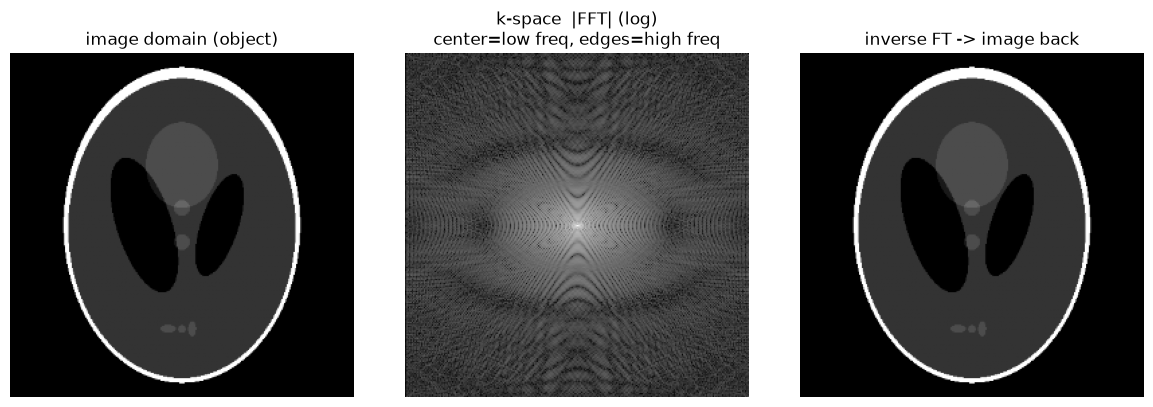

In [2]:
# A phantom and its 2D k-space (Fourier) representation
img = resize(shepp_logan_phantom(), (256, 256), anti_aliasing=True)

kspace = np.fft.fftshift(np.fft.fft2(img))        # complex k-space
kmag   = np.log1p(np.abs(kspace))                 # log magnitude for display
recon  = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace)))  # inverse FT -> image

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img, cmap="gray");   ax[0].set_title("image domain (object)")
ax[1].imshow(kmag, cmap="gray");  ax[1].set_title("k-space  |FFT| (log)\ncenter=low freq, edges=high freq")
ax[2].imshow(recon, cmap="gray"); ax[2].set_title("inverse FT -> image back")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

## 4. Projection-reconstruction: the Radon view
Rotate the readout gradient to many angles $\phi$ (0–179°). Each readout is a **k-space projection**;
equivalently each is a **projection of the object** at angle $\phi$. Stacking all projections forms the
**Radon space** (a *sinogram*). The **inverse Radon transform** reconstructs the tomographic slice.
This is the Nobel-winning projection-reconstruction idea (Lauterbur/Mansfield, 2003).

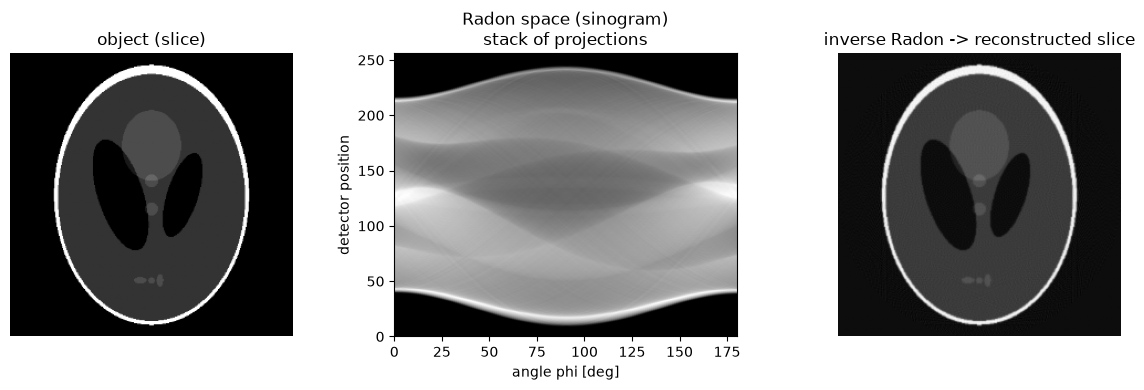

In [3]:
angles = np.arange(0, 180, 1.0)             # projection angles phi (deg)
sinogram = radon(img, theta=angles)         # Radon space: stack of projections
fbp = iradon(sinogram, theta=angles, filter_name="ramp")   # inverse Radon (FBP)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("object (slice)"); ax[0].axis("off")
ax[1].imshow(sinogram, cmap="gray", aspect="auto",
             extent=(0, 180, 0, sinogram.shape[0]))
ax[1].set_title("Radon space (sinogram)\nstack of projections")
ax[1].set_xlabel("angle phi [deg]"); ax[1].set_ylabel("detector position")
ax[2].imshow(fbp, cmap="gray"); ax[2].set_title("inverse Radon -> reconstructed slice"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## 5. Cartesian k-space traversal: gradients steer a “turtle”
Instead of radial projections, we can walk through k-space on a grid by controlling $G_x$ and $G_y$
during readout. The k-space coordinate reached at time $t$ is
$$k_x = \frac{\gamma}{2\pi}\,G_x\,t, \qquad k_y = \frac{\gamma}{2\pi}\,A_y,\quad A_y = G_y\,t_p,$$
where $A_y$ is the **area** of the phase-encoding gradient (amplitude $G_y$ × duration $t_p$). Adjusting
$G_x, G_y$ moves the acquisition point anywhere in k-space (raster, radial, spiral …) — like a
turtle-graphics pen driven by the gradients.

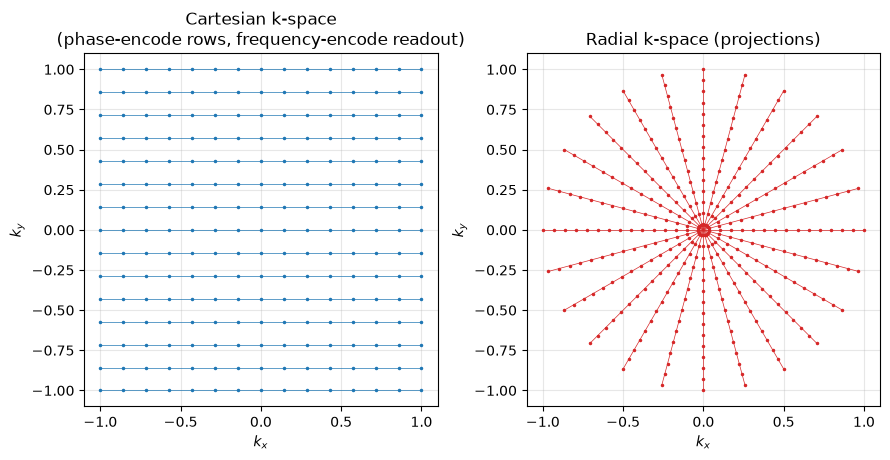

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))

# Cartesian raster sampling (frequency encode along kx, phase encode steps along ky)
kx = np.linspace(-1, 1, 15)
for ky in np.linspace(-1, 1, 15):
    ax[0].plot(kx, np.full_like(kx, ky), ".-", color="tab:blue", lw=0.5, ms=3)
ax[0].set_title("Cartesian k-space\n(phase-encode rows, frequency-encode readout)")
ax[0].set_xlabel("$k_x$"); ax[0].set_ylabel("$k_y$")

# Radial spokes (projection-reconstruction)
r = np.linspace(-1, 1, 30)
for phi in np.linspace(0, np.pi, 12, endpoint=False):
    ax[1].plot(r*np.cos(phi), r*np.sin(phi), ".-", color="tab:red", lw=0.5, ms=3)
ax[1].set_title("Radial k-space (projections)")
ax[1].set_xlabel("$k_x$"); ax[1].set_ylabel("$k_y$")
for a in ax:
    a.set_aspect("equal"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. The 2D Fourier transform pair
k-space (coordinates $u,v$ or $k_x,k_y$) and the image (coordinates $x,y$) are a **2D Fourier
transform** pair:
$$F(k_x,k_y) = \iint f(x,y)\,e^{-i2\pi(k_x x + k_y y)}\,dx\,dy.$$
k-space is **complex** (real + imaginary); the displayed image is the **magnitude** $|f(x,y)|$ of the
inverse transform in each voxel. The name **k** comes from the *wave number* in X-ray crystallography:
higher energy → shorter wavelength → finer resolvable spacing (k at the edge of k-space).

## 7. Gradient-echo pulse sequence
Sequence of events (repeated for each phase-encode step):
1. **Slice select** — $G_z$ + RF excitation covering the slice's frequency band; the 90° tip starts
   precession.
2. **Phase encode** — a $G_y$ pulse (stepped to a *different value each repetition*) to move to a new
   $k_y$ row.
3. **Frequency encode / readout** — $G_x$ with a **negative lobe then positive lobe**: spins first
   **dephase**, then when the gradient flips they **rephase**, producing a **gradient echo**.
4. **ADC** records the echo.

Timing: **TE** (echo time) = pulse start → echo peak; **TR** (repetition time) = time to repeat the
whole sequence for the next phase-encode step. The echo forms because reversing the gradient's sign
undoes the accumulated phase (the spin *direction* is unchanged — only the gradient orientation flips).

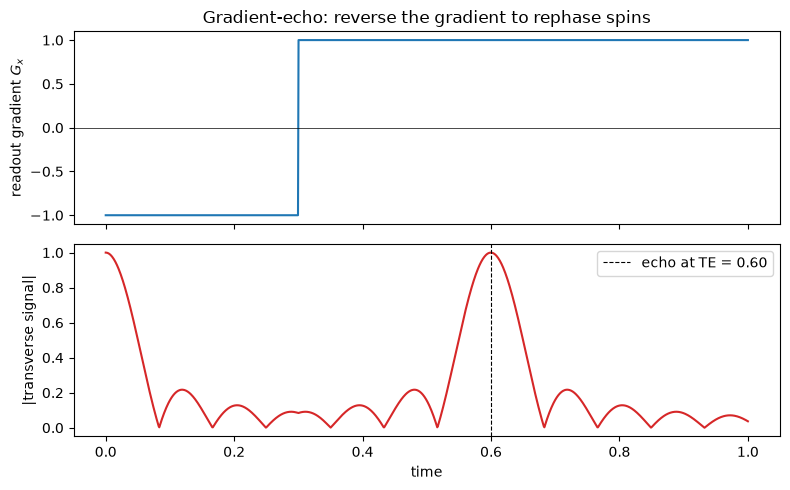

In [5]:
# Gradient-echo formation: isochromats dephase under a -G lobe, then rephase under +G -> echo
N = 600
x = np.linspace(-1, 1, N)                 # spin positions across the readout direction
t = np.linspace(0, 1.0, 1200)
t_rev = 0.3                               # time when the readout gradient flips sign

G = np.where(t < t_rev, -1.0, 1.0)        # readout gradient waveform (dephase then rephase)
area = np.concatenate([[0.0], np.cumsum(0.5 * (G[1:] + G[:-1]) * np.diff(t))])  # gradient area
kt = 6.0 * area                           # k(t) ~ (gamma/2pi) * area  (arbitrary scale)

# Net transverse signal = |sum of isochromat phasors|; peaks when k(t)=0 (t=0 and t=2*t_rev)
signal = np.abs(np.mean(np.exp(1j * 2 * np.pi * np.outer(kt, x)), axis=1))
TE = 2 * t_rev

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(t, G, color="tab:blue"); ax[0].axhline(0, color="k", lw=0.5)
ax[0].set_ylabel("readout gradient $G_x$"); ax[0].set_title("Gradient-echo: reverse the gradient to rephase spins")
ax[1].plot(t, signal, color="tab:red")
ax[1].axvline(TE, color="k", ls="--", lw=0.8, label=f"echo at TE = {TE:.2f}")
ax[1].set_xlabel("time"); ax[1].set_ylabel("|transverse signal|"); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Why “frequency” encoding vs “phase” encoding?
- **Frequency encoding** ($G_x$ during readout): position sets the *precession frequency*, so each
  $x$ contributes a different frequency to the readout — traversed as $k_x=\frac{\gamma}{2\pi}G_x t$.
- **Phase encoding** ($G_y$ before readout): a brief gradient sets a position-dependent *starting
  phase*; stepping its area $A_y=G_y t_p$ moves to different $k_y$ rows.

The 2D Fourier transform needs exactly these two pieces — **starting phase** and **frequency** — to
place each signal at its $(x,y)$ location. Two orthogonal Fourier transforms (one per encode
direction) turn the stacked readouts into the tomographic image.

## 9. Oversampling the center → filtered back-projection
Radial/polar sampling passes through the **center of k-space** repeatedly, oversampling low
frequencies and blurring the image. **Filtered back-projection** (a ramp filter in the inverse
Radon transform — the `filter_name="ramp"` above) compensates for this. We revisit this with the
math when we cover **CT** image formation.

## 10. Next steps & assignment
- **Assignment 3 Part 2:** load a provided **3D k-space** (complex numbers) into MATLAB, inverse
  Fourier transform it to the image domain, write a **VTK** volume, and visualize slices in
  **ParaView** (follow the posted “load 3D k-space” notes).
- **Next class:** **spin-echo** imaging — creating an echo by rephasing dephased spins with a **180°
  RF pulse** instead of a gradient reversal.

### Key takeaways
- A readout gradient makes each recorded signal a **line/projection in k-space**.
- **k-space ↔ image** via the 2D Fourier transform; center = contrast, edges = detail.
- Reconstruct either by **projection/Radon** (radial) or by **Cartesian** $k_x,k_y$ traversal using
  $G_x$ (frequency) and $G_y$ (phase) encoding.
- A **gradient echo** forms by reversing the readout gradient; **TE/TR** set echo and repetition timing.